# Explainable AI Credit Risk Assessment System
### Taiwan Default Credit Card Dataset — Full Pipeline
**Research Question:** Which class imbalance correction technique best preserves SHAP feature-ranking stability (measured via SRA)?

---
**Layers:**
1. Data Loading, EDA & Preprocessing
2. Imbalance Correction (SMOTE, ADASYN, Borderline-SMOTE, Class Weights, Threshold Moving)
3. XGBoost Model Training & Evaluation
4. SHAP Explainability
5. SRA (Spearman Rank Agreement) — Research Contribution
---

## STEP 0 — Install All Required Libraries
Run this cell ONCE. Restart the kernel after installation if needed.

In [2]:
# Run this cell once to install everything
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'xgboost', 'imbalanced-learn',
    'shap', 'scipy', 'openpyxl', 'xlrd'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed successfully!')

All packages installed successfully!


## STEP 1 — Import Libraries

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve
)
from sklearn.utils import resample

# Imbalance correction
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap

# Stats
from scipy.stats import spearmanr

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print('All imports successful!')
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

Matplotlib is building the font cache; this may take a moment.


All imports successful!
NumPy: 2.4.6
Pandas: 3.0.3


## STEP 2 — Load the Dataset
**Important:** Change the file path below to match where you saved your file.
Example: `C:/Users/sangita/Downloads/default of credit card clients.xls`

In [4]:
# =========================================================
# CHANGE THIS PATH TO WHERE YOU SAVED YOUR FILE
# =========================================================
FILE_PATH = r'C:\Users\sangita\Downloads\default of credit card clients.xls'
# =========================================================

# Load the dataset — skip the first row which is a secondary header
df = pd.read_excel(FILE_PATH, header=1)

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded successfully!
Shape: 30,000 rows x 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## STEP 3 — Understand the Columns

In [5]:
print('Column names:')
print(df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Data types:
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      in

In [6]:
# Rename the target column for clarity (it may be called 'default payment next month')
# Find the target column automatically
target_candidates = [c for c in df.columns if 'default' in c.lower()]
print('Candidate target columns:', target_candidates)

# Rename to standard name
df.rename(columns={target_candidates[0]: 'DEFAULT'}, inplace=True)

# Also drop the ID column if present
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)
    print('Dropped ID column')

print('Target column: DEFAULT')
print('Value counts:')
print(df['DEFAULT'].value_counts())
print(f'\nClass imbalance ratio: {df["DEFAULT"].value_counts()[0]/df["DEFAULT"].value_counts()[1]:.1f}:1')

Candidate target columns: ['default payment next month']
Dropped ID column
Target column: DEFAULT
Value counts:
DEFAULT
0    23364
1     6636
Name: count, dtype: int64

Class imbalance ratio: 3.5:1


## STEP 4 — Exploratory Data Analysis (EDA)

In [7]:
# Basic statistics
print('Basic Statistics:')
df.describe()

Basic Statistics:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000
mean,167484.3227,1.6037,1.8531,1.5519,35.4855,-0.0167,-0.1338,-0.1662,-0.2207,-0.2662,-0.2911,51223.3309,49179.0752,47013.1548,43262.9490,40311.4010,38871.7604,5663.5805,5921.1635,5225.6815,4826.0769,4799.3876,5215.5026,0.2212
std,129747.6616,0.4891,0.7903,0.5220,9.2179,1.1238,1.1972,1.1969,1.1691,1.1332,1.1500,73635.8606,71173.7688,69349.3874,64332.8561,60797.1558,59554.1075,16563.2804,23040.8704,17606.9615,15666.1597,15278.3057,17777.4658,0.4151
min,10000.0000,1.0000,0.0000,0.0000,21.0000,-2.0000,-2.0000,-2.0000,-2.0000,-2.0000,-2.0000,-165580.0000,-69777.0000,-157264.0000,-170000.0000,-81334.0000,-339603.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,50000.0000,1.0000,1.0000,1.0000,28.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,3558.7500,2984.7500,2666.2500,2326.7500,1763.0000,1256.0000,1000.0000,833.0000,390.0000,296.0000,252.5000,117.7500,0.0000
50%,140000.0000,2.0000,2.0000,2.0000,34.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,22381.5000,21200.0000,20088.5000,19052.0000,18104.5000,17071.0000,2100.0000,2009.0000,1800.0000,1500.0000,1500.0000,1500.0000,0.0000
75%,240000.0000,2.0000,2.0000,2.0000,41.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,67091.0000,64006.2500,60164.7500,54506.0000,50190.5000,49198.2500,5006.0000,5000.0000,4505.0000,4013.2500,4031.5000,4000.0000,0.0000
max,1000000.0000,2.0000,6.0000,3.0000,79.0000,8.0000,8.0000,8.0000,8.0000,8.0000,8.0000,964511.0000,983931.0000,1664089.0000,891586.0000,927171.0000,961664.0000,873552.0000,1684259.0000,896040.0000,621000.0000,426529.0000,528666.0000,1.0000


In [8]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

Missing values per column:
No missing values found!


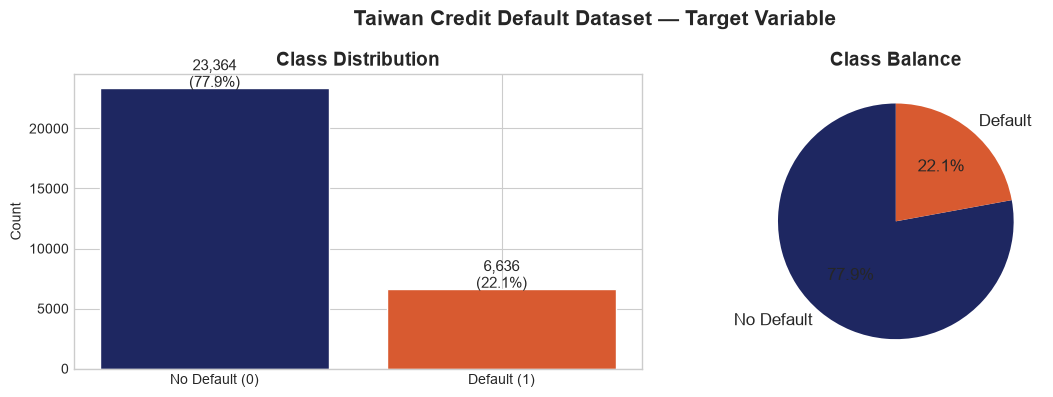

Chart saved!


In [9]:
# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['DEFAULT'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=['#1E2761', '#D85A30'], edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['No Default', 'Default'],
            colors=['#1E2761', '#D85A30'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.suptitle('Taiwan Credit Default Dataset — Target Variable', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

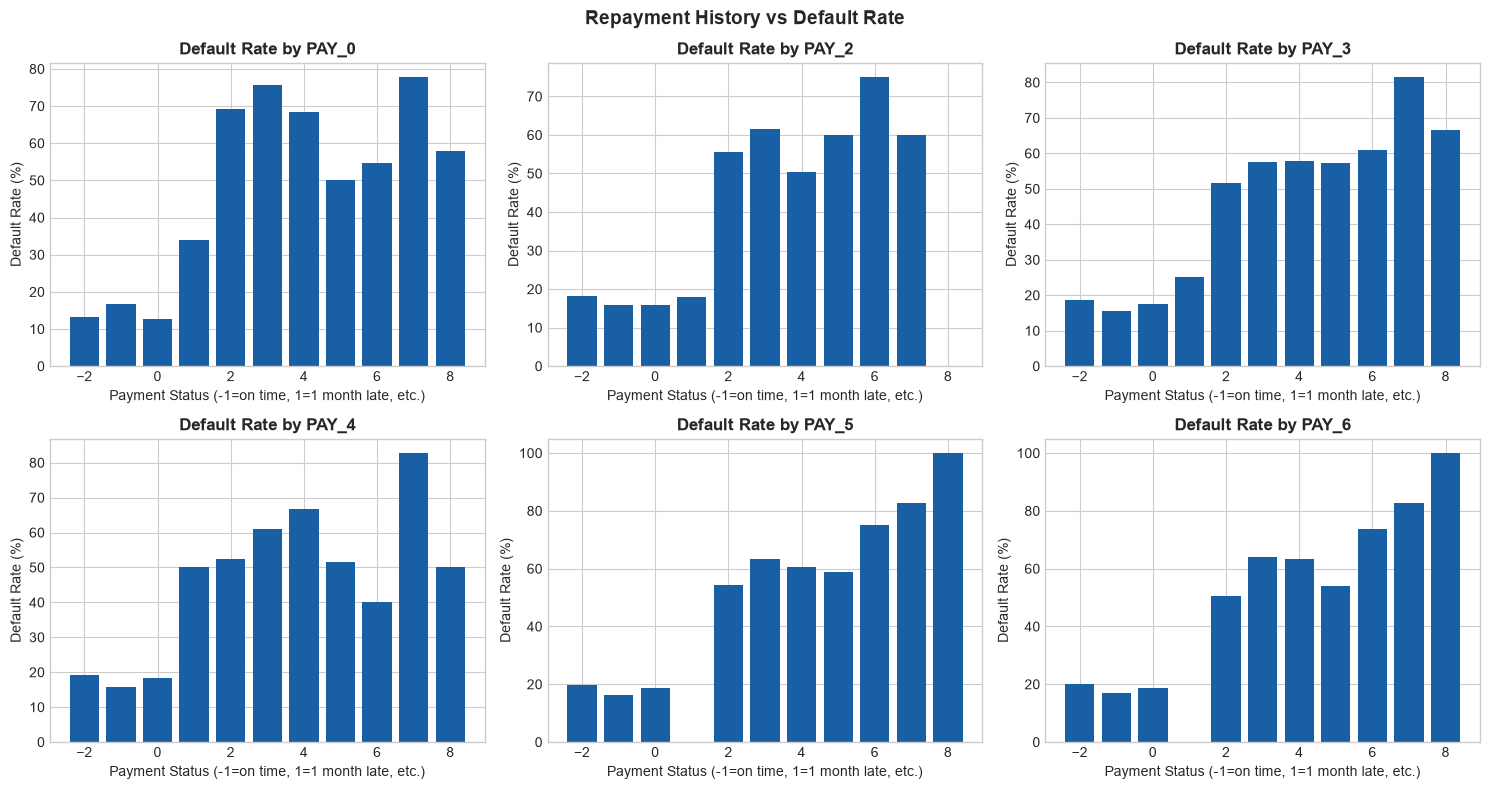

In [10]:
# Plot 2: Default rate by Repayment Status (PAY_0 is the most recent month)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for i, col in enumerate(pay_cols):
    if col in df.columns:
        default_rates = df.groupby(col)['DEFAULT'].mean() * 100
        axes[i].bar(default_rates.index, default_rates.values, color='#185FA5')
        axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
        axes[i].set_xlabel('Payment Status (-1=on time, 1=1 month late, etc.)')
        axes[i].set_ylabel('Default Rate (%)')

plt.suptitle('Repayment History vs Default Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_repayment_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

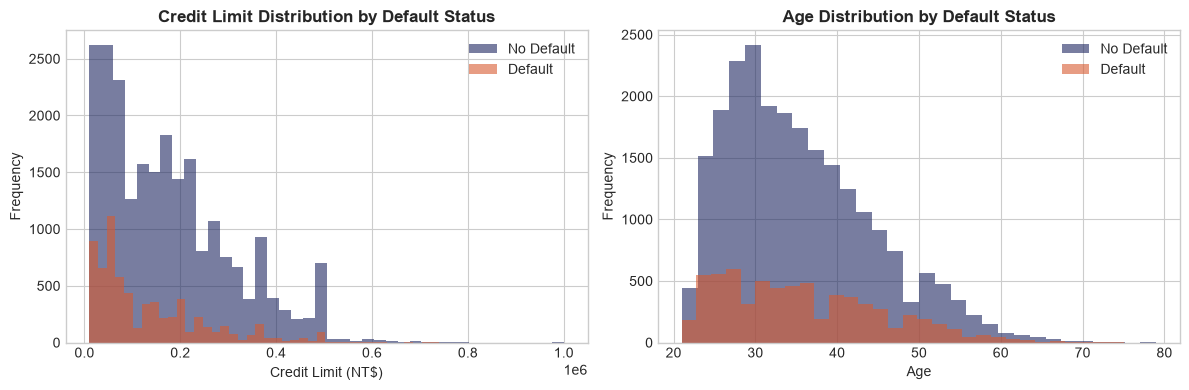

In [11]:
# Plot 3: Credit limit distribution by default status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['DEFAULT'] == 0]['LIMIT_BAL'].plot.hist(bins=40, alpha=0.6, color='#1E2761',
                                               label='No Default', ax=axes[0])
df[df['DEFAULT'] == 1]['LIMIT_BAL'].plot.hist(bins=40, alpha=0.6, color='#D85A30',
                                               label='Default', ax=axes[0])
axes[0].set_title('Credit Limit Distribution by Default Status', fontweight='bold')
axes[0].set_xlabel('Credit Limit (NT$)')
axes[0].legend()

# Age distribution
df[df['DEFAULT'] == 0]['AGE'].plot.hist(bins=30, alpha=0.6, color='#1E2761',
                                         label='No Default', ax=axes[1])
df[df['DEFAULT'] == 1]['AGE'].plot.hist(bins=30, alpha=0.6, color='#D85A30',
                                         label='Default', ax=axes[1])
axes[1].set_title('Age Distribution by Default Status', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('03_credit_limit_age.png', dpi=150, bbox_inches='tight')
plt.show()

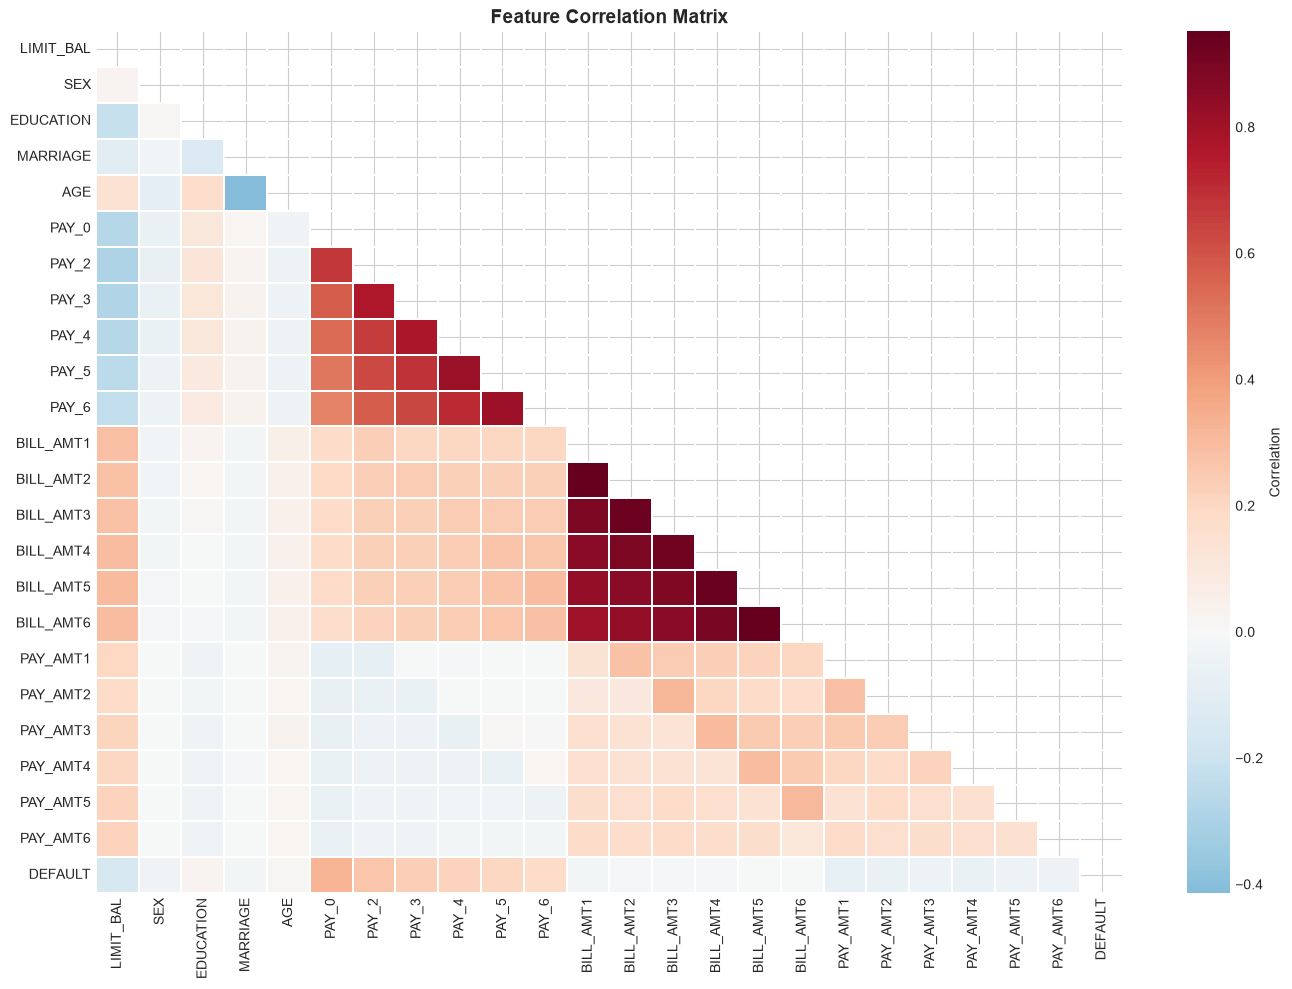

In [12]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.3, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 5 — Preprocessing

In [13]:
# 1. Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Removed {before - after} duplicate rows. Remaining: {after:,}')

# 2. Clean invalid category values
# SEX: should be 1 or 2
# EDUCATION: 1=graduate, 2=university, 3=high school, 4=others
# MARRIAGE: 1=married, 2=single, 3=others
# Values of 0 in these columns are often undocumented — recode to 'other'

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})  # Collapse unknowns to 'others'
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})  # Collapse unknown to 'others'

print('Cleaned EDUCATION and MARRIAGE categories')
print('EDUCATION value counts:', df['EDUCATION'].value_counts().to_dict())
print('MARRIAGE value counts:', df['MARRIAGE'].value_counts().to_dict())

Removed 35 duplicate rows. Remaining: 29,965
Cleaned EDUCATION and MARRIAGE categories
EDUCATION value counts: {2: 14019, 1: 10563, 3: 4915, 4: 468}
MARRIAGE value counts: {2: 15945, 1: 13643, 3: 377}


In [14]:
# 3. Feature Engineering — add useful derived features

# Average payment delay over 6 months
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['AVG_PAY_DELAY'] = df[pay_cols].mean(axis=1)

# Total bill amount over 6 months
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)

# Total payment amount over 6 months
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['TOTAL_PAID'] = df[pay_amt_cols].sum(axis=1)

# Credit utilisation ratio
df['UTIL_RATIO'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)  # +1 avoids division by zero

# Payment ratio (how much of the bill they paid)
df['PAY_RATIO'] = df['TOTAL_PAID'] / (df['TOTAL_BILL'] + 1)

print('New features added:')
print(' - AVG_PAY_DELAY: average payment delay across 6 months')
print(' - TOTAL_BILL: total billed over 6 months')
print(' - TOTAL_PAID: total paid over 6 months')
print(' - UTIL_RATIO: credit utilisation ratio')
print(' - PAY_RATIO: payment-to-bill ratio')
print(f'\nFinal shape: {df.shape}')

New features added:
 - AVG_PAY_DELAY: average payment delay across 6 months
 - TOTAL_BILL: total billed over 6 months
 - TOTAL_PAID: total paid over 6 months
 - UTIL_RATIO: credit utilisation ratio
 - PAY_RATIO: payment-to-bill ratio

Final shape: (29965, 29)


In [15]:
# 4. Separate features and target
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

feature_names = X.columns.tolist()
print(f'Features (X): {X.shape[1]} columns')
print(f'Target (y): {y.shape[0]:,} samples')
print(f'Default rate: {y.mean()*100:.1f}%')
print('\nFeature names:', feature_names)

Features (X): 28 columns
Target (y): 29,965 samples
Default rate: 22.1%

Feature names: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_PAY_DELAY', 'TOTAL_BILL', 'TOTAL_PAID', 'UTIL_RATIO', 'PAY_RATIO']


In [16]:
# 5. Train/Test Split (stratified to preserve class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples | Default rate: {y_train.mean()*100:.1f}%')
print(f'Test set:      {X_test.shape[0]:,} samples  | Default rate: {y_test.mean()*100:.1f}%')
print('Stratification confirmed: both sets have similar default rates')

Training set:  20,975 samples | Default rate: 22.1%
Test set:      8,990 samples  | Default rate: 22.1%
Stratification confirmed: both sets have similar default rates


In [17]:
# 6. Scale features (important for Logistic Regression; does not affect XGBoost but we do it for consistency)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_names)

print('Feature scaling complete (StandardScaler)')
print('Note: scaler was FIT on training data only, then APPLIED to test data')

Feature scaling complete (StandardScaler)
Note: scaler was FIT on training data only, then APPLIED to test data


## STEP 6 — Apply Imbalance Correction Methods
**Important:** Imbalance correction is ONLY applied to TRAINING data. Never to test data.

In [18]:
print('Original training set class distribution:')
print(y_train.value_counts())
print(f'Minority class (default=1): {y_train.sum():,} samples ({y_train.mean()*100:.1f}%)')

Original training set class distribution:
DEFAULT
0    16334
1     4641
Name: count, dtype: int64
Minority class (default=1): 4,641 samples (22.1%)


In [19]:
# SMOTE — Synthetic Minority Over-sampling Technique
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

print('SMOTE applied:')
print(f'  Before: {len(y_train):,} samples | After: {len(y_smote):,} samples')
print(f'  Class 0: {(y_smote==0).sum():,} | Class 1: {(y_smote==1).sum():,}')

SMOTE applied:
  Before: 20,975 samples | After: 32,668 samples
  Class 0: 16,334 | Class 1: 16,334


In [20]:
# ADASYN — Adaptive Synthetic Sampling
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

print('ADASYN applied:')
print(f'  Before: {len(y_train):,} samples | After: {len(y_adasyn):,} samples')
print(f'  Class 0: {(y_adasyn==0).sum():,} | Class 1: {(y_adasyn==1).sum():,}')

ADASYN applied:
  Before: 20,975 samples | After: 32,317 samples
  Class 0: 16,334 | Class 1: 15,983


In [21]:
# Borderline-SMOTE
bl_smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_blsmote, y_blsmote = bl_smote.fit_resample(X_train_scaled, y_train)

print('Borderline-SMOTE applied:')
print(f'  Before: {len(y_train):,} samples | After: {len(y_blsmote):,} samples')
print(f'  Class 0: {(y_blsmote==0).sum():,} | Class 1: {(y_blsmote==1).sum():,}')

Borderline-SMOTE applied:
  Before: 20,975 samples | After: 32,668 samples
  Class 0: 16,334 | Class 1: 16,334


In [22]:
# Class Weights — no resampling, just pass scale_pos_weight to XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print(f'Class weight ratio (scale_pos_weight): {scale_pos_weight_value:.2f}')
print('This means: misclassifying a default is penalised', round(scale_pos_weight_value, 1), 'x more')

Class weight ratio (scale_pos_weight): 3.52
This means: misclassifying a default is penalised 3.5 x more


## STEP 7 — Train XGBoost Models for Each Method

In [23]:
# Helper function to train and evaluate a model
def train_and_evaluate(X_tr, y_tr, X_te, y_te, method_name, scale_pos_weight=1):
    """
    Train XGBoost and return model + metrics dict.
    X_tr, y_tr: training data (after imbalance correction applied)
    X_te, y_te: test data (always the original, unmodified test set)
    """
    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,  # Only used for class weights method
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    )
    
    model.fit(X_tr, y_tr, verbose=False)
    
    # Predict
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Metrics
    roc = roc_auc_score(y_te, y_pred_proba)
    f1  = f1_score(y_te, y_pred)
    
    print(f'\n{method_name}:')
    print(f'  ROC-AUC: {roc:.4f}')
    print(f'  F1 Score: {f1:.4f}')
    print(classification_report(y_te, y_pred, target_names=['No Default', 'Default']))
    
    return model, {'method': method_name, 'roc_auc': roc, 'f1': f1}

print('Helper function defined. Now training models...')

Helper function defined. Now training models...


In [24]:
# Train model with each method
results = []
models  = {}
X_trains = {}
y_trains  = {}

# Method 1: SMOTE
m, r = train_and_evaluate(X_smote, y_smote, X_test_scaled, y_test, 'SMOTE')
models['SMOTE'] = m; results.append(r)
X_trains['SMOTE'] = X_smote; y_trains['SMOTE'] = y_smote


SMOTE:
  ROC-AUC: 0.7706
  F1 Score: 0.5011
              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      7001
     Default       0.58      0.44      0.50      1989

    accuracy                           0.81      8990
   macro avg       0.72      0.68      0.69      8990
weighted avg       0.79      0.81      0.80      8990



In [25]:
# Method 2: ADASYN
m, r = train_and_evaluate(X_adasyn, y_adasyn, X_test_scaled, y_test, 'ADASYN')
models['ADASYN'] = m; results.append(r)
X_trains['ADASYN'] = X_adasyn; y_trains['ADASYN'] = y_adasyn


ADASYN:
  ROC-AUC: 0.7660
  F1 Score: 0.4934
              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      7001
     Default       0.58      0.43      0.49      1989

    accuracy                           0.80      8990
   macro avg       0.71      0.67      0.69      8990
weighted avg       0.79      0.80      0.79      8990



In [26]:
# Method 3: Borderline-SMOTE
m, r = train_and_evaluate(X_blsmote, y_blsmote, X_test_scaled, y_test, 'Borderline-SMOTE')
models['Borderline-SMOTE'] = m; results.append(r)
X_trains['Borderline-SMOTE'] = X_blsmote; y_trains['Borderline-SMOTE'] = y_blsmote


Borderline-SMOTE:
  ROC-AUC: 0.7680
  F1 Score: 0.5001
              precision    recall  f1-score   support

  No Default       0.85      0.90      0.87      7001
     Default       0.56      0.45      0.50      1989

    accuracy                           0.80      8990
   macro avg       0.70      0.68      0.69      8990
weighted avg       0.79      0.80      0.79      8990



In [27]:
# Method 4: Class Weights (train on original unmodified data, pass weight to model)
m, r = train_and_evaluate(X_train_scaled, y_train, X_test_scaled, y_test,
                           'Class Weights', scale_pos_weight=scale_pos_weight_value)
models['Class Weights'] = m; results.append(r)
X_trains['Class Weights'] = X_train_scaled; y_trains['Class Weights'] = y_train


Class Weights:
  ROC-AUC: 0.7800
  F1 Score: 0.5329
              precision    recall  f1-score   support

  No Default       0.88      0.81      0.84      7001
     Default       0.48      0.60      0.53      1989

    accuracy                           0.77      8990
   macro avg       0.68      0.71      0.69      8990
weighted avg       0.79      0.77      0.77      8990



In [28]:
# Method 5: Threshold Moving
# First train a normal model, then find the optimal threshold using Precision-Recall curve

# Train base model
base_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, use_label_encoder=False
)
base_model.fit(X_train_scaled, y_train, verbose=False)

# Find optimal threshold (maximise F1)
y_proba_base = base_model.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_base)
f1_scores_thresh = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores_thresh[:-1])]

print(f'Default threshold: 0.50 → F1: {f1_score(y_test, (y_proba_base>=0.5).astype(int)):.4f}')
print(f'Optimal threshold: {optimal_threshold:.3f} → F1: {f1_scores_thresh.max():.4f}')

# Store with optimal threshold applied
y_pred_thresh = (y_proba_base >= optimal_threshold).astype(int)
r_thresh = {
    'method': 'Threshold Moving',
    'roc_auc': roc_auc_score(y_test, y_proba_base),
    'f1': f1_score(y_test, y_pred_thresh)
}
models['Threshold Moving'] = base_model; results.append(r_thresh)
X_trains['Threshold Moving'] = X_train_scaled; y_trains['Threshold Moving'] = y_train

print('Threshold Moving model stored!')

Default threshold: 0.50 → F1: 0.4817
Optimal threshold: 0.266 → F1: 0.5378
Threshold Moving model stored!


## STEP 8 — Compare Model Performance

In [29]:
# Summary table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1', ascending=False)
print('\nModel Performance Summary:')
print(results_df.to_string(index=False))


Model Performance Summary:
          method  roc_auc     f1
Threshold Moving   0.7821 0.5378
   Class Weights   0.7800 0.5329
           SMOTE   0.7706 0.5011
Borderline-SMOTE   0.7680 0.5001
          ADASYN   0.7660 0.4934


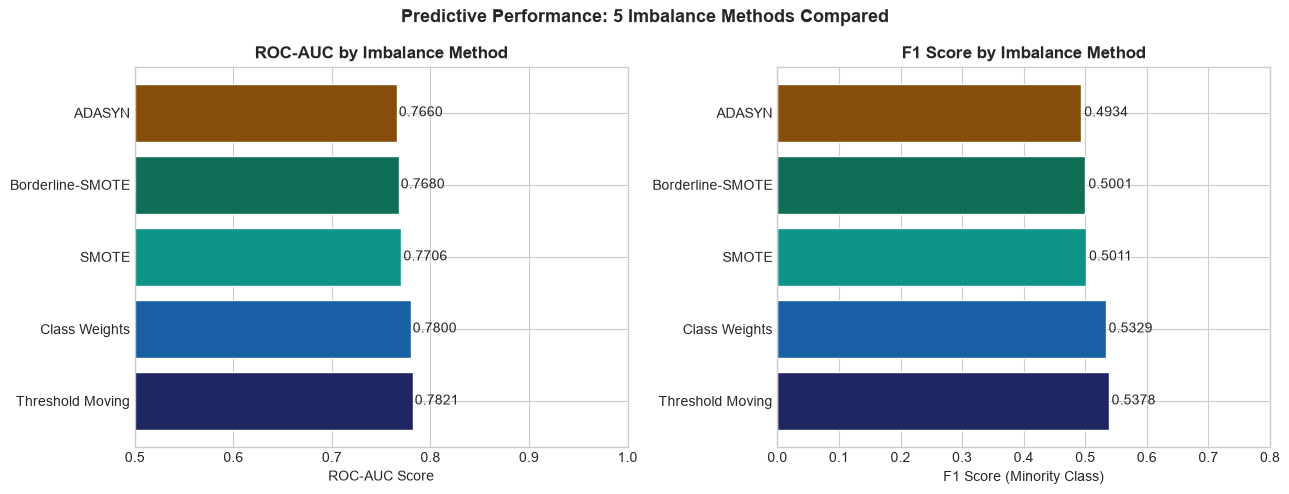

In [30]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#1E2761', '#185FA5', '#0D9488', '#0F6E56', '#854F0B']
methods_sorted = results_df['method'].tolist()

# ROC-AUC
bars1 = axes[0].barh(methods_sorted, results_df['roc_auc'], color=colors, edgecolor='white')
axes[0].set_xlim(0.5, 1.0)
axes[0].set_title('ROC-AUC by Imbalance Method', fontweight='bold', fontsize=12)
axes[0].set_xlabel('ROC-AUC Score')
for bar, val in zip(bars1, results_df['roc_auc']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

# F1
bars2 = axes[1].barh(methods_sorted, results_df['f1'], color=colors, edgecolor='white')
axes[1].set_xlim(0, 0.8)
axes[1].set_title('F1 Score by Imbalance Method', fontweight='bold', fontsize=12)
axes[1].set_xlabel('F1 Score (Minority Class)')
for bar, val in zip(bars2, results_df['f1']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Predictive Performance: 5 Imbalance Methods Compared', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 9 — SHAP Explainability

In [31]:
# Compute SHAP values for each model
# We use a sample of the test set for speed (500 samples is enough for global explanations)

shap_values_dict = {}
feature_importance_dict = {}

X_explain = X_test_scaled.sample(500, random_state=42)

for method_name, model in models.items():
    print(f'Computing SHAP for: {method_name}...')
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_explain)
    shap_values_dict[method_name] = shap_vals
    
    # Mean absolute SHAP = feature importance
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    feat_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)
    feature_importance_dict[method_name] = feat_importance
    print(f'  Done. Top feature: {feat_importance.index[0]}')

print('\nAll SHAP values computed!')

Computing SHAP for: SMOTE...
  Done. Top feature: PAY_0
Computing SHAP for: ADASYN...
  Done. Top feature: PAY_0
Computing SHAP for: Borderline-SMOTE...
  Done. Top feature: PAY_0
Computing SHAP for: Class Weights...
  Done. Top feature: PAY_0
Computing SHAP for: Threshold Moving...
  Done. Top feature: PAY_0

All SHAP values computed!


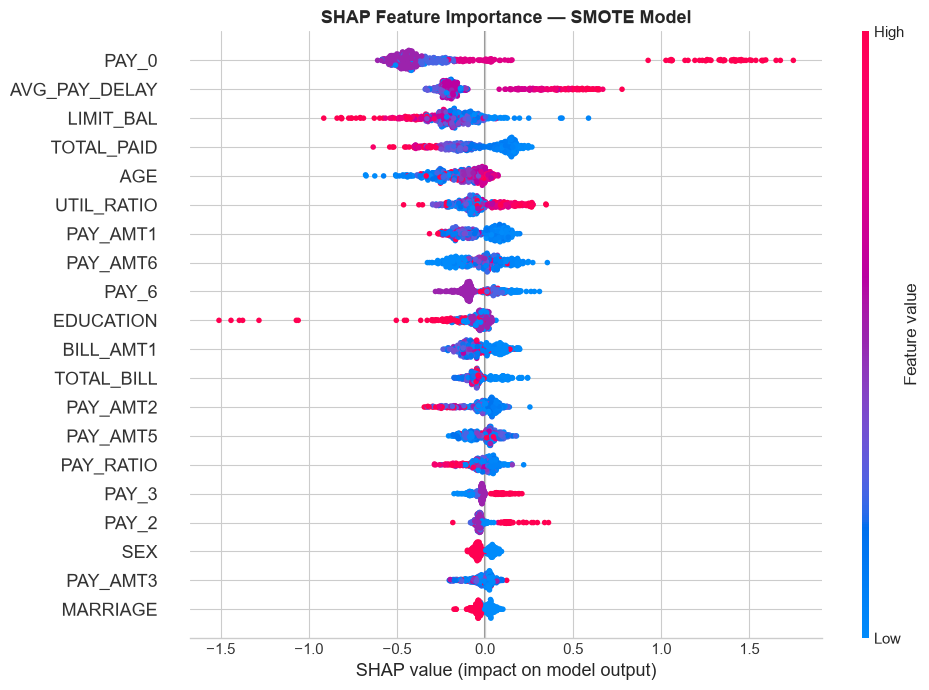

SHAP summary plot saved!


In [32]:
# SHAP Summary Plot for the SMOTE model (representative)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_dict['SMOTE'],
    X_explain,
    feature_names=feature_names,
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP Feature Importance — SMOTE Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_shap_summary_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary plot saved!')

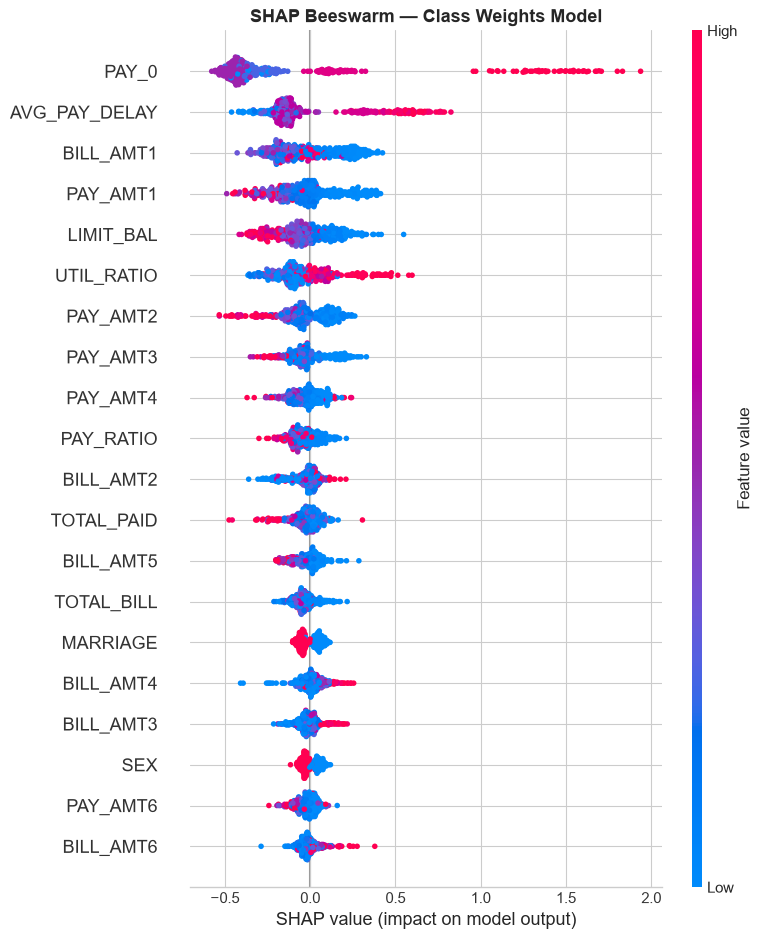

In [33]:
# SHAP Beeswarm for Class Weights model
shap.summary_plot(
    shap_values_dict['Class Weights'],
    X_explain,
    feature_names=feature_names,
    plot_type='dot',
    show=False
)
plt.title('SHAP Beeswarm — Class Weights Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_shap_beeswarm_classweights.png', dpi=150, bbox_inches='tight')
plt.show()

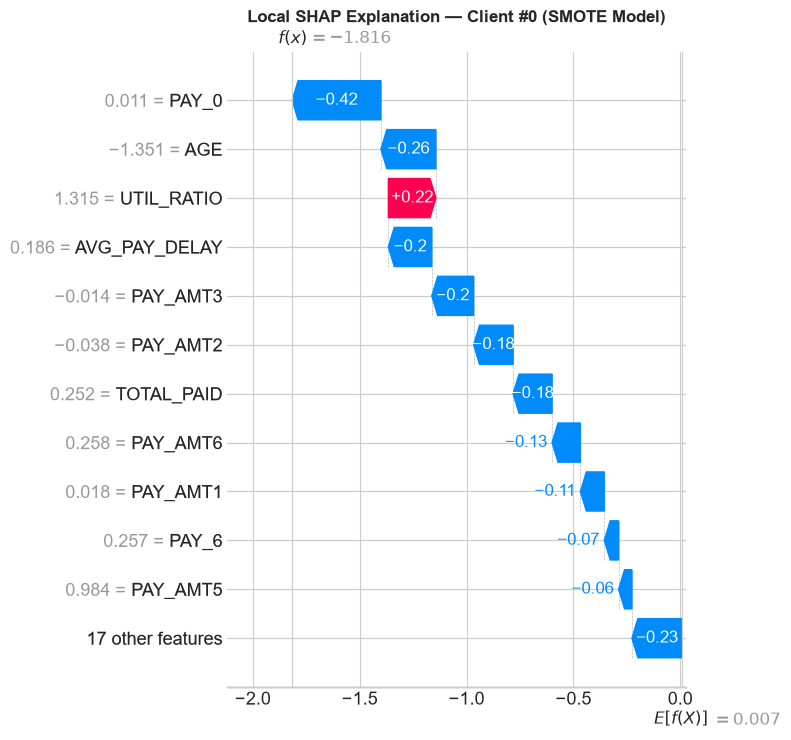

Local explanation saved!


In [34]:
# Local explanation — SHAP waterfall for ONE specific client
# Let's pick the first sample in our explain set

sample_idx = 0
explainer_smote = shap.TreeExplainer(models['SMOTE'])
shap_explanation = explainer_smote(X_explain.iloc[[sample_idx]])

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation[0], max_display=12, show=False)
plt.title(f'Local SHAP Explanation — Client #{sample_idx} (SMOTE Model)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('08_shap_local_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Local explanation saved!')

In [35]:
# Compare feature rankings across all 5 methods
print('Top 10 Feature Rankings by Method:\n')

ranking_df = pd.DataFrame()
for method, importance in feature_importance_dict.items():
    ranking_df[method] = range(1, len(importance)+1)
    ranking_df.index = importance.index

# Reconstruct properly
rankings = {}
for method, importance in feature_importance_dict.items():
    ranked_features = importance.rank(ascending=False).astype(int)
    rankings[method] = ranked_features

ranking_compare = pd.DataFrame(rankings)
ranking_compare['avg_rank'] = ranking_compare.mean(axis=1)
ranking_compare_sorted = ranking_compare.sort_values('avg_rank').head(10)
print(ranking_compare_sorted.drop('avg_rank', axis=1))

Top 10 Feature Rankings by Method:

               SMOTE  ADASYN  Borderline-SMOTE  Class Weights  \
PAY_0              1       1                 1              1   
AVG_PAY_DELAY      2       3                 3              2   
LIMIT_BAL          3       2                 2              5   
UTIL_RATIO         6       6                 6              6   
TOTAL_PAID         4       5                 4             12   
BILL_AMT1         11      10                 8              3   
PAY_AMT1           7      11                13              4   
PAY_AMT2          13      12                11              7   
AGE                5       4                 5             22   
PAY_AMT6           8       7                 7             19   

               Threshold Moving  
PAY_0                         1  
AVG_PAY_DELAY                 2  
LIMIT_BAL                     4  
UTIL_RATIO                    5  
TOTAL_PAID                    8  
BILL_AMT1                     3  
PAY_AMT1  

## STEP 10 — SRA (Spearman Rank Agreement) — THE RESEARCH CONTRIBUTION
This is the core of the research question. We measure how stable the SHAP feature rankings are
across bootstrap samples for each imbalance method.

In [36]:
def compute_sra(model, X_data, feature_names, n_bootstrap=30, sample_frac=0.8, random_seed=42):
    """
    Compute Spearman Rank Agreement (SRA) for a given model.
    
    Algorithm:
    1. Bootstrap sample X_data n_bootstrap times
    2. Compute SHAP values for each sample
    3. Rank features by mean |SHAP| for each run
    4. Compute pairwise Spearman correlation between all pairs of runs
    5. Average all pairwise correlations = SRA
    """
    n = int(len(X_data) * sample_frac)
    explainer = shap.TreeExplainer(model)
    rankings_list = []
    
    np.random.seed(random_seed)
    
    for i in range(n_bootstrap):
        # Bootstrap sample
        idx = np.random.choice(len(X_data), size=n, replace=True)
        X_boot = X_data.iloc[idx]
        
        # SHAP values
        shap_vals = explainer.shap_values(X_boot)
        
        # Feature importance = mean absolute SHAP
        mean_abs = np.abs(shap_vals).mean(axis=0)
        
        # Rank (highest mean|SHAP| gets rank 1)
        ranks = pd.Series(mean_abs).rank(ascending=False).values
        rankings_list.append(ranks)
    
    # Compute all pairwise Spearman correlations
    correlations = []
    for i in range(n_bootstrap):
        for j in range(i+1, n_bootstrap):
            corr, _ = spearmanr(rankings_list[i], rankings_list[j])
            correlations.append(corr)
    
    sra_score = np.mean(correlations)
    sra_std   = np.std(correlations)
    return sra_score, sra_std

print('SRA function defined!')
print('This will take a few minutes (30 bootstrap iterations x 5 methods)...')

SRA function defined!
This will take a few minutes (30 bootstrap iterations x 5 methods)...


In [37]:
# Run SRA for all methods
# Using test set for SRA measurement (500 samples for speed)
X_sra = X_test_scaled.sample(500, random_state=42)

sra_results = []

for method_name, model in models.items():
    print(f'Computing SRA for {method_name}... ', end='')
    sra, sra_std = compute_sra(model, X_sra, feature_names, n_bootstrap=30)
    sra_results.append({'method': method_name, 'sra': sra, 'sra_std': sra_std})
    print(f'SRA = {sra:.4f} ± {sra_std:.4f}')

sra_df = pd.DataFrame(sra_results).sort_values('sra', ascending=False)
print('\nSRA Results (sorted by stability):')
print(sra_df.to_string(index=False))

Computing SRA for SMOTE... SRA = 0.9952 ± 0.0022
Computing SRA for ADASYN... SRA = 0.9941 ± 0.0027
Computing SRA for Borderline-SMOTE... SRA = 0.9932 ± 0.0028
Computing SRA for Class Weights... SRA = 0.9844 ± 0.0076
Computing SRA for Threshold Moving... SRA = 0.9854 ± 0.0073

SRA Results (sorted by stability):
          method    sra  sra_std
           SMOTE 0.9952   0.0022
          ADASYN 0.9941   0.0027
Borderline-SMOTE 0.9932   0.0028
Threshold Moving 0.9854   0.0073
   Class Weights 0.9844   0.0076


In [38]:
# Merge SRA and predictive performance for final comparison
final_df = pd.merge(results_df, sra_df, on='method')
final_df = final_df.sort_values('sra', ascending=False)

print('FINAL COMPARISON TABLE:')
print('='*70)
print(f'{"Method":<20} {"F1 Score":>10} {"ROC-AUC":>10} {"SRA":>10} {"SRA Std":>10}')
print('-'*70)
for _, row in final_df.iterrows():
    print(f'{row["method"]:<20} {row["f1"]:>10.4f} {row["roc_auc"]:>10.4f} {row["sra"]:>10.4f} {row["sra_std"]:>10.4f}')
print('='*70)

FINAL COMPARISON TABLE:
Method                 F1 Score    ROC-AUC        SRA    SRA Std
----------------------------------------------------------------------
SMOTE                    0.5011     0.7706     0.9952     0.0022
ADASYN                   0.4934     0.7660     0.9941     0.0027
Borderline-SMOTE         0.5001     0.7680     0.9932     0.0028
Threshold Moving         0.5378     0.7821     0.9854     0.0073
Class Weights            0.5329     0.7800     0.9844     0.0076


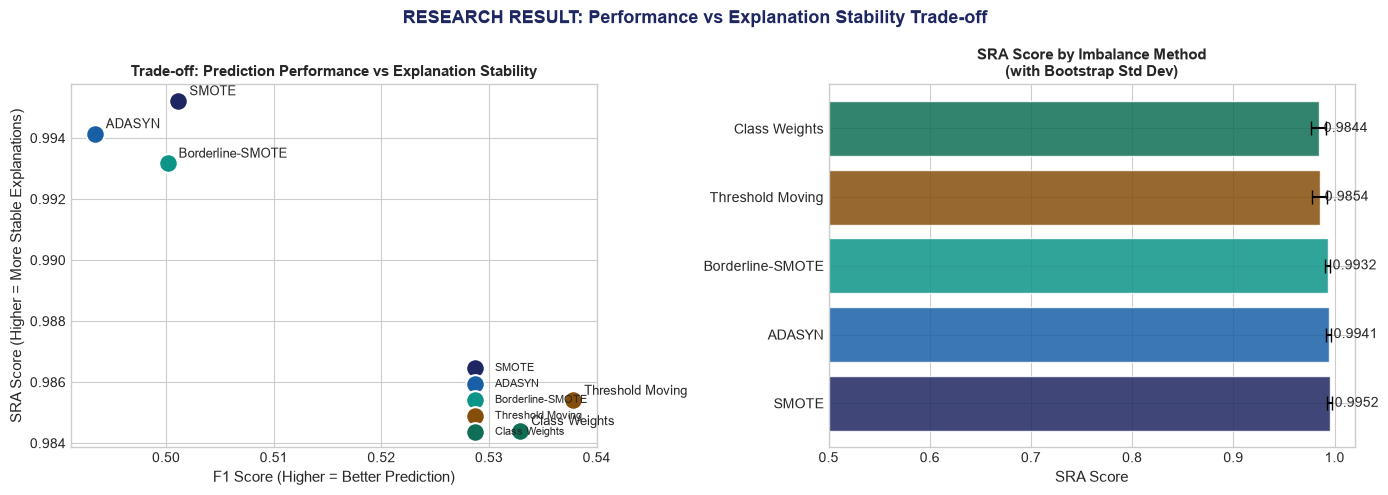

Final comparison chart saved!


In [39]:
# Final visualisation — SRA vs F1 Score (The Trade-off Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'SMOTE': '#1E2761', 'ADASYN': '#185FA5', 'Borderline-SMOTE': '#0D9488',
          'Class Weights': '#0F6E56', 'Threshold Moving': '#854F0B'}

# Scatter: F1 vs SRA (trade-off plot)
for _, row in final_df.iterrows():
    axes[0].scatter(row['f1'], row['sra'], s=180, color=colors[row['method']],
                   label=row['method'], zorder=5, edgecolor='white', linewidth=1.5)
    axes[0].annotate(row['method'], (row['f1'], row['sra']),
                    textcoords='offset points', xytext=(8, 4), fontsize=9)

axes[0].set_xlabel('F1 Score (Higher = Better Prediction)', fontsize=11)
axes[0].set_ylabel('SRA Score (Higher = More Stable Explanations)', fontsize=11)
axes[0].set_title('Trade-off: Prediction Performance vs Explanation Stability', fontweight='bold', fontsize=11)
axes[0].legend(loc='lower right', fontsize=8)

# Bar: SRA with error bars
bar_colors = [colors[m] for m in final_df['method']]
bars = axes[1].barh(final_df['method'], final_df['sra'], xerr=final_df['sra_std'],
                     color=bar_colors, alpha=0.85, capsize=5, edgecolor='white')
axes[1].set_xlim(0.5, 1.02)
axes[1].set_xlabel('SRA Score', fontsize=11)
axes[1].set_title('SRA Score by Imbalance Method\n(with Bootstrap Std Dev)', fontweight='bold', fontsize=11)
for bar, val in zip(bars, final_df['sra']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('RESEARCH RESULT: Performance vs Explanation Stability Trade-off', 
             fontsize=13, fontweight='bold', color='#1E2761')
plt.tight_layout()
plt.savefig('09_sra_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final comparison chart saved!')

In [40]:
# Print research findings summary
best_f1_method  = final_df.loc[final_df['f1'].idxmax(), 'method']
best_sra_method = final_df.loc[final_df['sra'].idxmax(), 'method']

print('='*65)
print('RESEARCH FINDINGS SUMMARY')
print('='*65)
print(f'\nBest F1 Score (prediction):       {best_f1_method}')
print(f'Best SRA (explanation stability): {best_sra_method}')

if best_f1_method != best_sra_method:
    print('\nFINDING: H2 SUPPORTED — There IS a trade-off!')
    print(f'  {best_f1_method} gives better predictions.')
    print(f'  {best_sra_method} gives more stable SHAP explanations.')
    print('  Banks should choose based on their priority:')
    print(f'  - Prediction focus  → use {best_f1_method}')
    print(f'  - Explainability focus → use {best_sra_method}')
else:
    print('\nFINDING: H2 NOT SUPPORTED — Same method wins on both metrics.')
    print(f'  {best_f1_method} is both the best predictor AND most stable.')

print('='*65)

RESEARCH FINDINGS SUMMARY

Best F1 Score (prediction):       Threshold Moving
Best SRA (explanation stability): SMOTE

FINDING: H2 SUPPORTED — There IS a trade-off!
  Threshold Moving gives better predictions.
  SMOTE gives more stable SHAP explanations.
  Banks should choose based on their priority:
  - Prediction focus  → use Threshold Moving
  - Explainability focus → use SMOTE


## STEP 11 — Save Results to CSV

In [41]:
# Save final comparison table
final_df.to_csv('sra_results_final.csv', index=False)
print('Results saved to sra_results_final.csv')
print(final_df)

Results saved to sra_results_final.csv
             method  roc_auc     f1    sra  sra_std
2             SMOTE   0.7706 0.5011 0.9952   0.0022
4            ADASYN   0.7660 0.4934 0.9941   0.0027
3  Borderline-SMOTE   0.7680 0.5001 0.9932   0.0028
0  Threshold Moving   0.7821 0.5378 0.9854   0.0073
1     Class Weights   0.7800 0.5329 0.9844   0.0076


---
## Summary of What This Notebook Does

| Step | What it does |
|------|-------------|
| 1-2  | Load Taiwan dataset (.xls from your Downloads folder) |
| 3-4  | EDA: class balance, repayment patterns, distributions |
| 5    | Preprocessing: clean, feature engineer, scale, split |
| 6    | Apply SMOTE, ADASYN, Borderline-SMOTE, Class Weights, Threshold Moving |
| 7    | Train one XGBoost model per imbalance method |
| 8    | Compare F1 and ROC-AUC across methods |
| 9    | SHAP global summary + local waterfall explanation |
| 10   | **SRA: research contribution** — measure explanation stability |
| 11   | Save results |

**Key output:** `sra_results_final.csv` — this is your research result table.

---